# Лабораторная работа №3: Классификация изображений (CIFAR-100) на PyTorch

**Вариант:** 13 | **Группа:** 1

### Цели работы:
1.  Изучить основы фреймворка **PyTorch**.
2.  Реализовать и обучить полносвязную нейронную сеть (MLP).
3.  Разобраться с математикой, стоящей за обучением (функции потерь, оптимизаторы).
4.  Экспортировать модель в формат **ONNX**.

---

In [1]:
# Установка зависимостей
!pip install torch torchvision numpy scikit-learn matplotlib onnx onnxscript seaborn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pickle
import os
from sklearn.metrics import classification_report, confusion_matrix
import torch.onnx

# Настройка стиля графиков для Retina дисплеев (MacBook)
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set(style="whitegrid", font_scale=1.2)

# Определение устройства (Apple Silicon M-series support)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✅ Устройство ускорения: MPS (Metal Performance Shaders) - Apple Silicon")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("✅ Устройство ускорения: CUDA (Nvidia)")
else:
    device = torch.device("cpu")
    print("⚠️ Устройство: CPU (Медленно)")

✅ Устройство ускорения: MPS (Metal Performance Shaders) - Apple Silicon


## 1. Подготовка и визуализация данных

**Математика нормализации:**
Изображения хранятся в формате RGB со значениями пикселей $[0, 255]$. Для нейронной сети предпочтительнее работать с диапазоном $[0, 1]$ или нормальным распределением. Мы используем масштабирование (MinMax Scaling):
$$
x_{norm} = \frac{x}{255.0}
$$

**Целевые классы (по варианту):**
1.  **1** — Аквариумная рыбка (Aquarium fish)
2.  **13** — Автобус (Bus)
3.  **43** — Лев (Lion)

In [3]:
if not os.path.exists('cifar-100-python'):
    !wget https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz
    !tar -xvzf cifar-100-python.tar.gz

TARGET_CLASSES = [1, 13, 43]
CLASS_NAMES = {1: "Fish", 13: "Bus", 43: "Lion"}

def load_and_filter_data(file_path, target_classes):
    with open(file_path, 'rb') as f:
        data_dict = pickle.load(f, encoding='latin1')
    
    images = data_dict['data']
    labels = np.array(data_dict['fine_labels'])
    
    # Фильтрация
    mask = np.isin(labels, target_classes)
    filtered_images = images[mask]
    filtered_labels = labels[mask]
    
    # Ремаппинг меток: {1, 13, 43} -> {0, 1, 2}
    label_map = {label: i for i, label in enumerate(target_classes)}
    mapped_labels = np.array([label_map[l] for l in filtered_labels])
    
    # CIFAR формат: [N, 3072] -> PyTorch формат: [N, 3, 32, 32]
    filtered_images = filtered_images.reshape(-1, 3, 32, 32)
    
    # Нормализация и перевод в тензоры
    tensor_x = torch.Tensor(filtered_images) / 255.0
    tensor_y = torch.LongTensor(mapped_labels)
    
    return tensor_x, tensor_y

# Загрузка данных
train_x, train_y = load_and_filter_data('cifar-100-python/train', TARGET_CLASSES)
test_x, test_y = load_and_filter_data('cifar-100-python/test', TARGET_CLASSES)

print(f"Обучающая выборка: {train_x.shape}")
print(f"Тестовая выборка: {test_x.shape}")

Обучающая выборка: torch.Size([1500, 3, 32, 32])
Тестовая выборка: torch.Size([300, 3, 32, 32])


/var/folders/17/316n_5bx1bx9vjrmz3_tqcrh0000gn/T/ipykernel_27522/1267472181.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(f, encoding='latin1')


Примеры изображений из обучающей выборки:


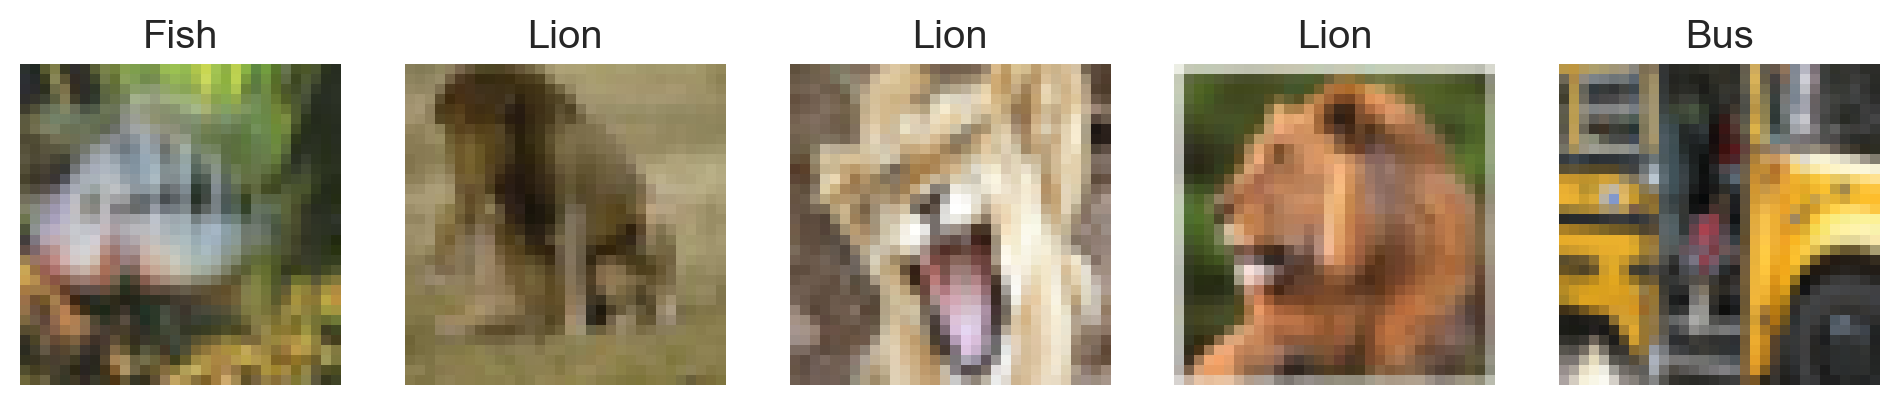

In [4]:
# Визуализация примеров из датасета
def show_samples(images, labels, class_names, num_samples=5):
    plt.figure(figsize=(12, 4))
    for i in range(num_samples):
        ax = plt.subplot(1, num_samples, i + 1)
        # PyTorch [C, H, W] -> Matplotlib [H, W, C]
        img = images[i].permute(1, 2, 0).numpy()
        label_idx = labels[i].item()
        original_label = TARGET_CLASSES[label_idx]
        
        plt.imshow(img)
        plt.title(f"{class_names[original_label]}")
        plt.axis("off")
    plt.show()

print("Примеры изображений из обучающей выборки:")
show_samples(train_x, train_y, CLASS_NAMES)

In [5]:
BATCH_SIZE = 64

train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(test_x, test_y), batch_size=BATCH_SIZE, shuffle=False)

## 2. Архитектура нейронной сети (MLP)

### Математическая модель полносвязного слоя
Один слой нейронной сети выполняет линейное преобразование входного вектора $x$, за которым следует нелинейная функция активации:

$$
y = \sigma(W x + b)
$$

где:
- $W$ — матрица весов (Weights),
- $b$ — вектор смещения (Bias),
- $\sigma$ — функция активации (в нашем случае ReLU).

### Функция активации ReLU
Используется для добавления нелинейности, что позволяет сети аппроксимировать сложные функции. 
$$
ReLU(x) = \max(0, x)
$$

In [6]:
class MLPModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLPModel, self).__init__()
        # Входной слой преобразует матрицу 3x32x32 в плоский вектор 3072
        self.flatten = nn.Flatten()
        
        # Последовательность слоев
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),   # Скрытый слой 1
            nn.ReLU(),                            # Нелинейность
            nn.Linear(hidden_size, hidden_size // 2), # Скрытый слой 2 (сужение)
            nn.ReLU(),
            nn.Linear(hidden_size // 2, num_classes) # Выходной слой
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

INPUT_SIZE = 32 * 32 * 3
HIDDEN_SIZE = 256
NUM_CLASSES = 3

# Инициализация модели и перенос на устройство (MPS)
model = MLPModel(INPUT_SIZE, HIDDEN_SIZE, NUM_CLASSES).to(device)
print(model)

MLPModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=3072, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)


## 3. Функция потерь и Оптимизатор

### Cross Entropy Loss (Перекрестная энтропия)
Используется для задач классификации. Она измеряет разницу между истинным распределением вероятностей (One-hot метки) и предсказанным.

$$
L = -\sum_{i=1}^{C} y_i \cdot \log(\hat{y}_i)
$$
где $\hat{y}_i$ — предсказание (после Softmax), $y_i$ — истинная метка.

### Стохастический градиентный спуск (SGD)
Обновляет веса $W$ в направлении антиградиента функции потерь:

$$
W_{t+1} = W_t - \eta \nabla L(W_t)
$$
где $\eta$ (learning rate) — скорость обучения.

In [7]:
# Функция для обучения и визуализации
def train_model(model, train_loader, test_loader, epochs=20, lr=0.01, device=device):
    criterion = nn.CrossEntropyLoss()
    # Momentum помогает ускорить сходимость, учитывая предыдущие градиенты
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    
    train_losses = []
    test_accuracies = []
    
    print(f"Начало обучения на {device}...")
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()         # Обнуление градиентов
            outputs = model(inputs)       # Прямой проход
            loss = criterion(outputs, labels) # Вычисление ошибки
            loss.backward()               # Обратное распространение (Backprop)
            optimizer.step()              # Обновление весов
            
            running_loss += loss.item()
        
        # Валидация
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        
        train_losses.append(epoch_loss)
        test_accuracies.append(epoch_acc)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%")
            
    return train_losses, test_accuracies

# Запуск обучения
losses, accuracies = train_model(model, train_loader, test_loader, epochs=25, lr=0.01)

Начало обучения на mps...
Epoch [5/25] | Loss: 0.6529 | Acc: 79.00%
Epoch [10/25] | Loss: 0.5085 | Acc: 80.67%
Epoch [15/25] | Loss: 0.4312 | Acc: 81.33%
Epoch [20/25] | Loss: 0.4511 | Acc: 83.00%
Epoch [25/25] | Loss: 0.2723 | Acc: 83.67%


## 4. Визуализация результатов обучения

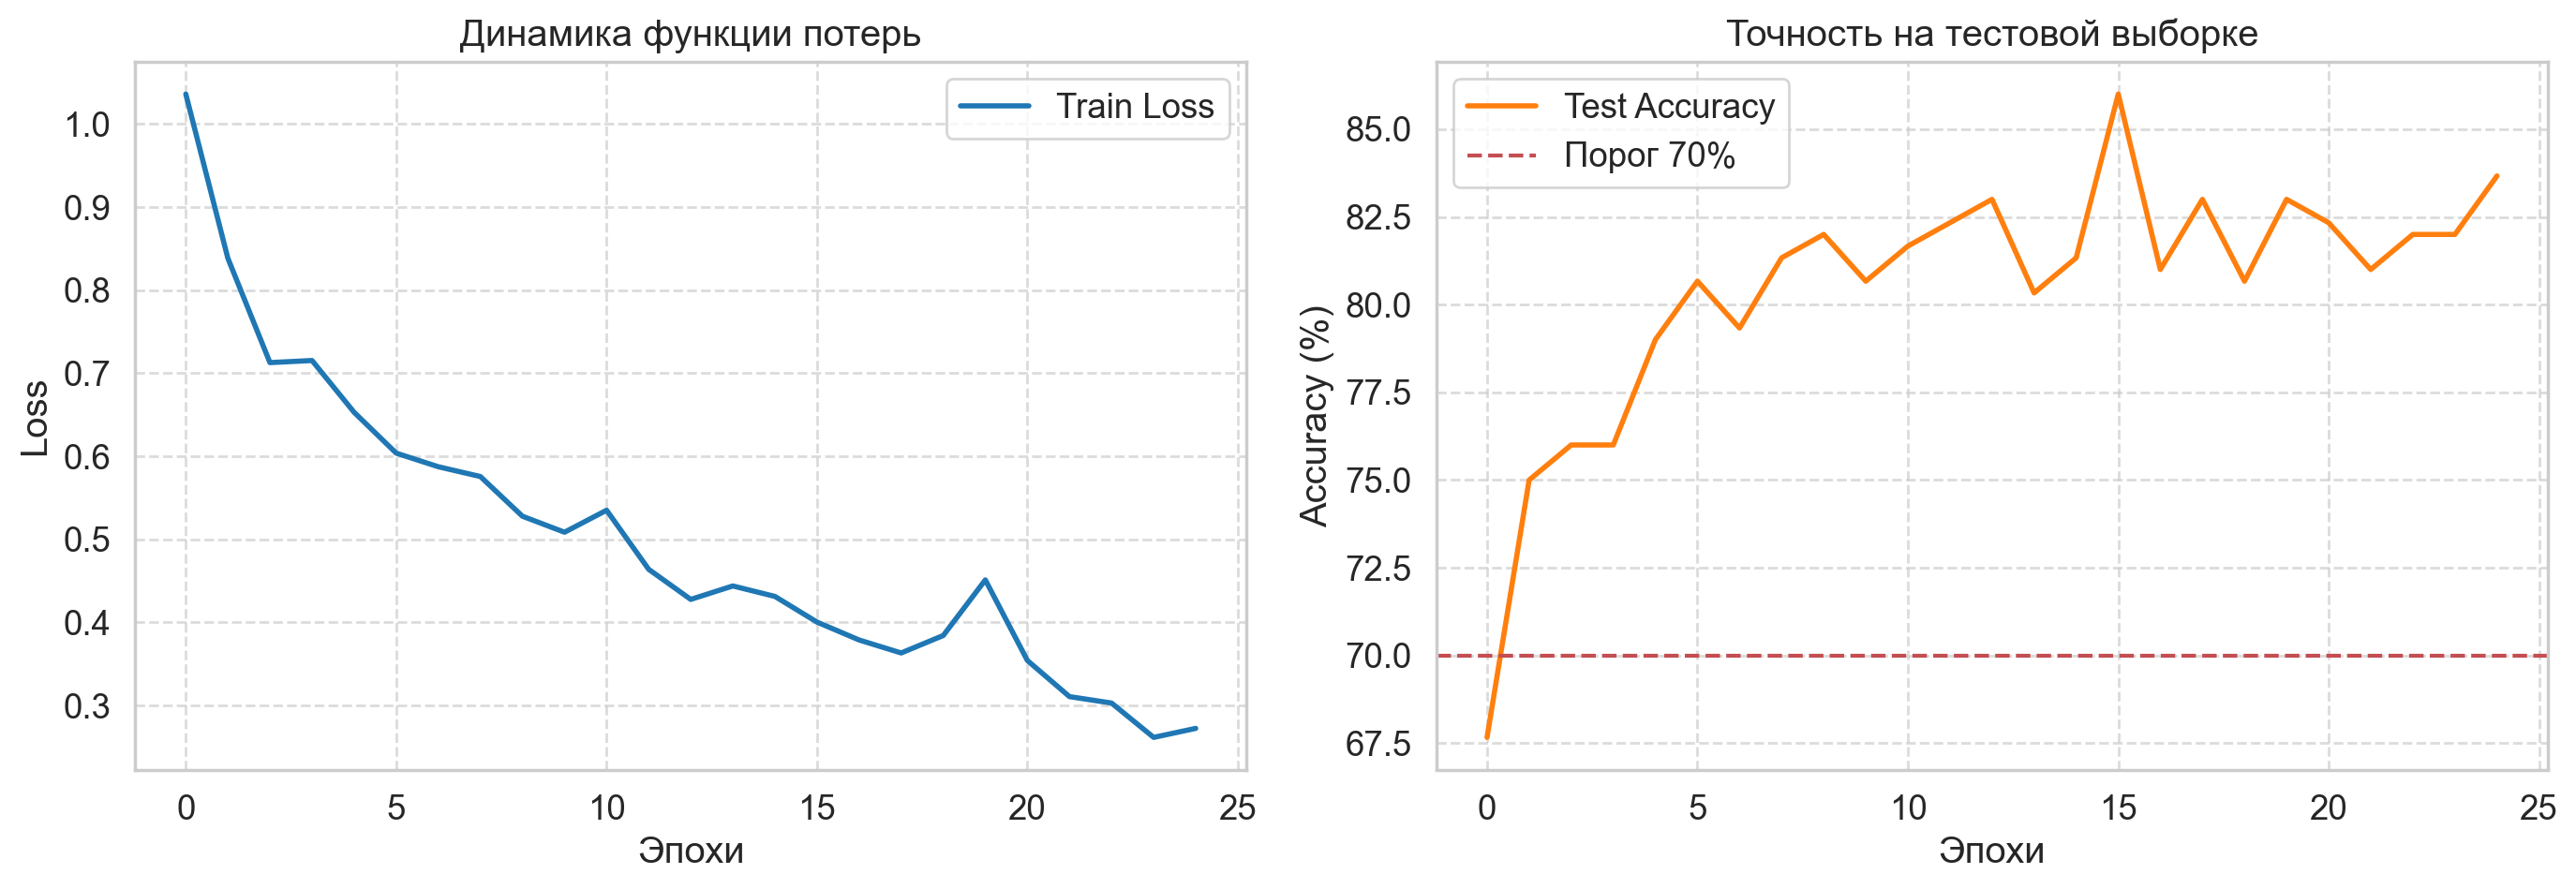

In [8]:
def plot_results(losses, accuracies):
    plt.figure(figsize=(14, 5))
    
    # График потерь
    plt.subplot(1, 2, 1)
    plt.plot(losses, label='Train Loss', color='tab:blue', linewidth=2)
    plt.title('Динамика функции потерь')
    plt.xlabel('Эпохи')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # График точности
    plt.subplot(1, 2, 2)
    plt.plot(accuracies, label='Test Accuracy', color='tab:orange', linewidth=2)
    plt.title('Точность на тестовой выборке')
    plt.xlabel('Эпохи')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axhline(y=70, color='r', linestyle='--', label='Порог 70%')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_results(losses, accuracies)

              precision    recall  f1-score   support

        Fish       0.76      0.89      0.82       100
         Bus       0.91      0.85      0.88       100
        Lion       0.86      0.77      0.81       100

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300



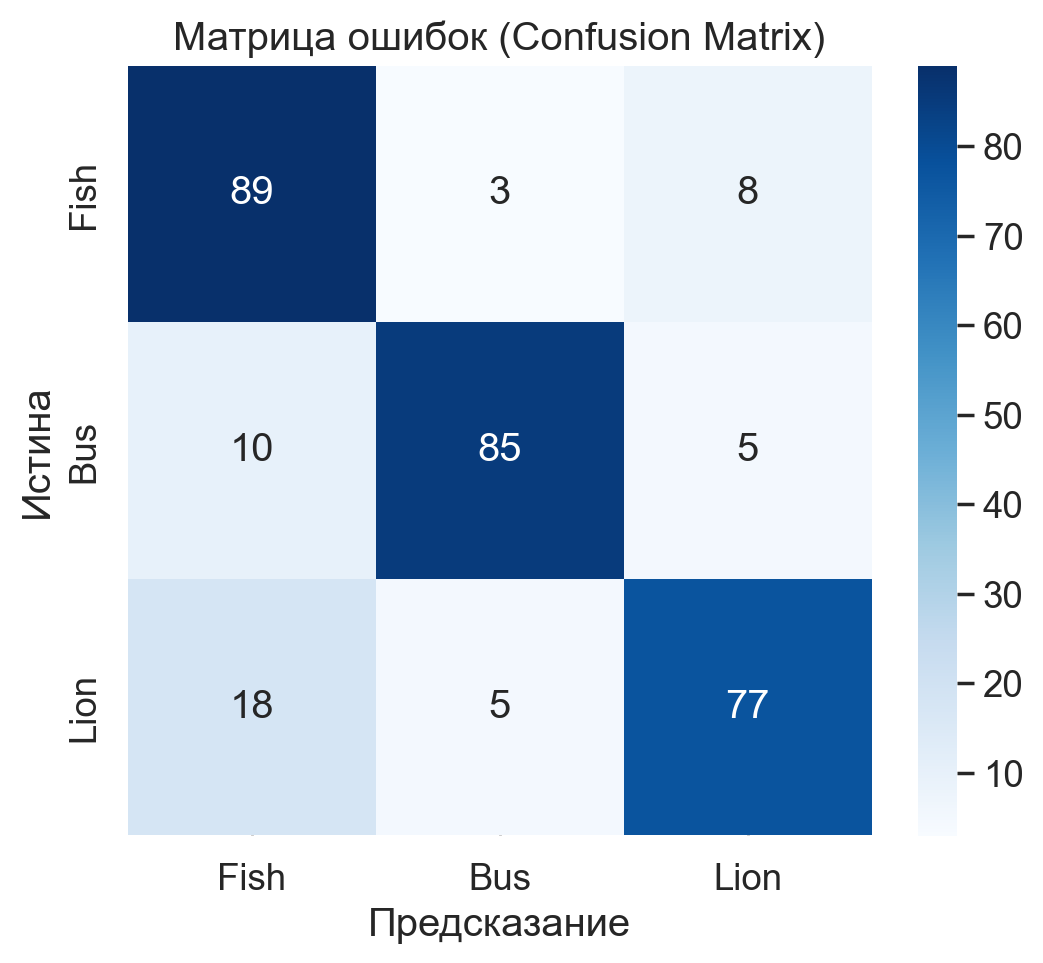

In [9]:
def evaluate_model(model, loader):
    model.eval()
    y_pred = []
    y_true = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            # Перенос на CPU для sklearn
            y_pred.extend(predicted.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
            
    # Отчет
    class_names_list = [CLASS_NAMES[c] for c in TARGET_CLASSES]
    print(classification_report(y_true, y_pred, target_names=class_names_list))
    
    # Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names_list, yticklabels=class_names_list)
    plt.title('Матрица ошибок (Confusion Matrix)')
    plt.xlabel('Предсказание')
    plt.ylabel('Истина')
    plt.show()

evaluate_model(model, test_loader)

## 5. Экспорт в ONNX
Open Neural Network Exchange (ONNX) — это открытый формат для представления моделей машинного обучения. Он позволяет переносить модели между фреймворками (например, обучить в PyTorch, а запустить в Unity или на мобильном устройстве).

In [10]:
# Важно: Перенос на CPU перед экспортом для стабильности
model_cpu = model.to("cpu")
model_cpu.eval()

dummy_input = torch.randn(1, 3, 32, 32, device="cpu")
onnx_path = "cifar100_model_v13.onnx"

torch.onnx.export(model_cpu, 
                  dummy_input, 
                  onnx_path, 
                  export_params=True,
                  opset_version=14,
                  do_constant_folding=True,
                  input_names = ['input'],
                  output_names = ['output'],
                  dynamic_axes={'input' : {0 : 'batch_size'}, 'output' : {0 : 'batch_size'}})

print(f"Модель успешно экспортирована в файл: {onnx_path}")

# Возврат на GPU для дальнейших экспериментов
model = model.to(device)

/var/folders/17/316n_5bx1bx9vjrmz3_tqcrh0000gn/T/ipykernel_27522/3824538728.py:8: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(model_cpu,
W1228 12:18:10.217000 27522 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MLPModel([...]` with `torch.export.export(..., strict=False)`...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 14).
Failed to convert the model to the target version 14 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/Volumes/university/education/7 term/mppr/labs/lab 3/venv/lib/python3.11/site-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Volumes/university/education/7 term/mppr/labs/lab 3/venv/lib/python3.11/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/Volumes/university/education/7 term/mppr/labs/lab 3/venv/lib/python3.11/site-packages/onnxscript/version_converter/__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.c

[torch.onnx] Obtain model graph for `MLPModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 1 of general pattern rewrite rules.
Модель успешно экспортирована в файл: cifar100_model_v13.onnx


## 6. Эксперименты с гиперпараметрами

Попробуем изменить:
1.  **Размер батча (Batch Size):** Влияет на стабильность градиента.
2.  **Скорость обучения (Learning Rate):** Влияет на скорость сходимости.

In [11]:
print("--- Эксперимент 1: Увеличение Batch Size (128) ---")
exp1_train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=128, shuffle=True)
exp1_model = MLPModel(INPUT_SIZE, HIDDEN_SIZE, NUM_CLASSES).to(device)
train_model(exp1_model, exp1_train_loader, test_loader, epochs=15, lr=0.01)

print("\n--- Эксперимент 2: Уменьшение Learning Rate (0.001) ---")
exp2_train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=64, shuffle=True)
exp2_model = MLPModel(INPUT_SIZE, HIDDEN_SIZE, NUM_CLASSES).to(device)
train_model(exp2_model, exp2_train_loader, test_loader, epochs=15, lr=0.001)
print("Эксперименты завершены.")

--- Эксперимент 1: Увеличение Batch Size (128) ---
Начало обучения на mps...
Epoch [5/15] | Loss: 0.7231 | Acc: 75.33%
Epoch [10/15] | Loss: 0.5939 | Acc: 80.33%
Epoch [15/15] | Loss: 0.5168 | Acc: 81.67%

--- Эксперимент 2: Уменьшение Learning Rate (0.001) ---
Начало обучения на mps...
Epoch [5/15] | Loss: 0.9716 | Acc: 70.00%
Epoch [10/15] | Loss: 0.7981 | Acc: 73.33%
Epoch [15/15] | Loss: 0.7054 | Acc: 76.33%
Эксперименты завершены.


## 7. Контрольные вопросы

1.  **Что такое функция потерь?**  
    Это математическая функция, которая оценивает, насколько предсказания модели отличаются от истинных значений. Задача обучения — минимизировать эту функцию.
2.  **Что такое оптимизатор?**  
    Алгоритм (например, SGD, Adam), который обновляет веса нейронной сети, используя градиенты, вычисленные функцией потерь, чтобы уменьшить ошибку.
3.  **Что такое эпоха, итерация и батч?**  
    *   **Эпоха:** Один полный проход через весь датасет.
    *   **Батч:** Небольшая группа примеров, обрабатываемых за раз.
    *   **Итерация:** Одно обновление весов (проход одного батча). В эпохе столько итераций, сколько батчей в датасете.

## 1. Строительные блоки (Архитектура)

### Нейрон, Веса и Смещения
Представь, что нейрон — это маленький решатель. Ему на вход приходят сигналы (числа).
*   **Вес ($w$, Weight):** Это важность входного сигнала. Если мы хотим определить, есть ли на фото лев, пиксель с "желтой шерстью" будет иметь большой вес, а пиксель с "синим небом" — маленький. Обучение сети — это просто поиск правильных чисел для этих весов.
*   **Смещение ($b$, Bias):** Это порог чувствительности. Он позволяет нейрону срабатывать, даже если все входы равны нулю (сдвигает график функции).
*   **Формула:** $y = \text{Вход} \cdot \text{Вес} + \text{Смещение}$

### Полносвязный слой (Fully Connected / Linear)
Это группа нейронов. В вашей лабе использовался слой `nn.Linear`.
*   **Суть:** Каждый входной пиксель соединен с каждым нейроном этого слоя.
*   **Аналогия:** Представь толпу людей, где каждый кричит каждому свою версию правды. Слой пытается из этого шума выделить важные признаки.
*   **В коде:** `nn.Linear(3072, 256)` означает, что мы берем 3072 входных значения (пиксели) и превращаем их в 256 новых признаков.

### Функция активации (Activation Function)
Сама по себе сумма взвешенных чисел ($Wx + b$) — это линейная операция. Но мир нелинеен (нельзя просто сложить яркость пикселей и получить "кошку").
*   **Зачем нужна:** Чтобы сеть могла понимать сложные формы, изгибы, зависимости. Она "искривляет" пространство решений.
*   **ReLU (Rectified Linear Unit):** Самая популярная активация. Работает как фейс-контроль:
    *   Положительное число? Проходи.
    *   Отрицательное? Ты теперь ноль.
    *   *Почему это эффективно:* Это отсекает лишний "шум" и делает вычисления очень быстрыми.

### Softmax
Стоит в самом конце. Нейросеть выдает на выходе какие-то странные числа (логиты), например: `[2.5, -0.1, 5.0]`. Нам нужно превратить их в вероятности.
*   **Softmax** делает так, чтобы все числа были от 0 до 1, а их сумма давала ровно 1.0 (100%).
*   Пример: `[10%, 2%, 88%]`. Вывод: это с вероятностью 88% лев.

---

## 2. Процесс обучения (Как сеть умнеет)

Обучение — это процесс подбора весов ($w$), при которых ошибки минимальны. Это происходит в три этапа: **Прямой проход $\to$ Оценка ошибки $\to$ Работа над ошибками**.

### Функция Потерь (Loss Function)
Это инструмент, который говорит, насколько сильно сеть ошиблась.
*   Мы показываем сети фото Льва.
*   Сеть говорит: "Это Автобус с вероятностью 80%".
*   **Loss** считает разницу между правдой (100% Лев) и ответом сети. Чем больше ошибка, тем больше число Loss.
*   **Наша цель:** Сделать Loss равным 0.

### Градиент (Gradient)
Представь, что ты стоишь на вершине горы туманной ночью. Тебе нужно спуститься в самую низкую долину (найти минимум ошибки), но ты ничего не видишь.
*   Ты ощупываешь землю ногами, чтобы понять, в какую сторону идет наклон вниз.
*   **Градиент** — это вектор, который показывает направление **самого крутого подъема** в гору.
*   Чтобы спуститься (уменьшить ошибку), нам нужно идти в сторону, **противоположную градиенту** (Антиградиент).

### Обратное распространение (Backpropagation)
Это ключевой алгоритм обучения нейросетей.
1.  Мы посчитали ошибку (Loss) в самом конце сети.
2.  Теперь мы идем от конца к началу и вычисляем, какой вклад в эту ошибку внес каждый конкретный нейрон.
3.  "Ты, нейрон №5 в слое 2, из-за тебя мы ошиблись сильнее всего! Тебе нужно сильно изменить свой вес".
4.  PyTorch делает это автоматически командой `loss.backward()`.

### Оптимизатор (Optimizer)
Это алгоритм, который фактически меняет веса, используя Градиент.
*   **SGD (Stochastic Gradient Descent):** Самый простой. Он берет градиент и делает маленький шаг в сторону улучшения.
*   **Learning Rate (Скорость обучения):** Это длина шага.
    *   *Большой шаг:* Можно перепрыгнуть яму (минимум) и улететь не туда.
    *   *Маленький шаг:* Будем спускаться с горы тысячу лет.

---

## 3. Работа с данными

### Тензор (Tensor)
Это просто контейнер для цифр.
*   Число (скаляр) — тензор 0-го ранга.
*   Список (вектор) — тензор 1-го ранга.
*   Таблица (матрица) — тензор 2-го ранга (например, черно-белая картинка).
*   **Тензор в PyTorch** — это многомерная матрица, которая умеет жить на видеокарте (GPU) и запоминать, какие математические операции с ней делали (чтобы потом посчитать градиент).

### Батч (Batch)
Сети не учатся по одной картинке за раз (это нестабильно — одна странная картинка может сбить сеть с толку). И не учатся на всех 60 000 картинках сразу (не влезет в память).
*   Мы кормим сеть **Батчами** (пакетами). Например, по 64 картинки.
*   Ошибка считается средняя по всему пакету. Это делает спуск к минимуму ошибки более плавным и уверенным.

### Эпоха (Epoch)
Когда сеть посмотрела **все** доступные картинки (все батчи) один раз — это одна эпоха. Обычно нужно 10-50 эпох, чтобы сеть выучила материал. Это как перечитывать учебник перед экзаменом несколько раз.

---

## Краткий словарь

1.  **Model (Модель):** Сама нейросеть (архитектура).
2.  **Train:** Процесс обучения (меняем веса).
3.  **Eval / Test:** Процесс проверки (веса заморожены, просто смотрим результат).
4.  **Weights (Веса):** Знания нейросети. Числа, которые мы подбираем.
5.  **Hyperparameters:** Настройки, которые задает человек *до* обучения (размер батча, Learning Rate, количество слоев). Они не обучаются сами.

## Уровень 1: Базовый
*Вопросы на проверку того, что студент сам запускал код и понимает основные термины.*

1.  **Что такое CIFAR-100?**
    *   Это набор данных из 60 000 цветных изображений размером 32x32 пикселя, разделенных на 100 классов.
2.  **Какие классы были в вашем варианте?**
    *   Аквариумная рыбка (1), Автобус (13), Лев (43).
3.  **Что такое Тензор (Tensor) в PyTorch?**
    *   Основная структура данных в PyTorch, похожая на многомерный массив (матрицу), но умеющая работать на GPU и хранить историю операций для вычисления градиентов.
4.  **Зачем мы делим данные на обучающую (train) и тестовую (test) выборки?**
    *   На обучающей модель учится (настраивает веса), а на тестовой мы проверяем ее реальное качество на данных, которые она раньше не видела, чтобы исключить простое запоминание.
5.  **Что такое Эпоха (Epoch)?**
    *   Один полный проход алгоритма обучения через весь датасет.
6.  **Что такое Батч (Batch)?**
    *   Небольшая группа изображений (например, 64 штуки), которые подаются в нейросеть одновременно для одного шага обновления весов. Это ускоряет обучение и стабилизирует градиент.
7.  **Зачем мы делим входные данные на 255.0?**
    *   Для нормализации. Изначально пиксели имеют значения от 0 до 255. Нейросетям математически проще и эффективнее работать с диапазоном чисел от 0 до 1.

---

## Уровень 2: Средний
*Вопросы по архитектуре, процессу обучения и функциям активации.*

1.  **Объясните архитектуру вашей нейросети (SimpleMLP).**
    *   Это полносвязная сеть. Сначала слой `Flatten` разворачивает картинку 32x32x3 в длинный вектор (размерностью 3072). Затем идут линейные слои (`Linear`), которые постепенно уменьшают размерность (3072 -> 256 -> 128 -> 3). Между линейными слоями стоит функция активации ReLU.
2.  **Что такое функция активации и зачем она нужна?**
    *   Это функция, которая принимает сумму входов нейрона и преобразует её в выходной сигнал.
    *   **Главная цель:** Добавить нелинейность. Без функций активации вся нейросеть, независимо от количества слоев, математически превратилась бы в одну большую линейную регрессию ($W_2(W_1 x) = W_{total} x$). Нелинейность позволяет сети решать сложные задачи (например, классифицировать изображения).
3.  **Какие функции активации вы знаете?**
    *   **Sigmoid (Сигмоида):** Сжимает значение в диапазон (0, 1).
    *   **Tanh (Гиперболический тангенс):** Сжимает в диапазон (-1, 1).
    *   **ReLU (Rectified Linear Unit):** Оставляет положительные значения как есть, отрицательные зануляет.
    *   **Softmax:** Превращает выходы последнего слоя в распределение вероятностей (сумма всех выходов равна 1).
4.  **Что делает `optimizer.zero_grad()` и зачем он нужен?**
    *   Он обнуляет градиенты перед каждым новым шагом обучения. В PyTorch градиенты по умолчанию накапливаются (суммируются) при каждом вызове `backward()`. Если их не сбрасывать, обучение будет некорректным.
5.  **Что такое Learning Rate (скорость обучения)?**
    *   Это коэффициент, определяющий, насколько сильно изменяются веса модели на каждом шаге. Если он слишком большой — модель "проскочит" минимум ошибки, если слишком маленький — будет учиться очень долго.
6.  **Что такое Функция Потерь (Loss Function)?**
    *   Функция, которая оценивает, насколько сильно ошиблась сеть (разница между предсказанным ответом и правильной меткой). Использовалась `CrossEntropyLoss` (стандарт для задач классификации).
7.  **Что такое переобучение (overfitting)?**
    *   Ситуация, когда модель просто запомнила тренировочные данные, но не выучила общие закономерности. На графиках это выглядит так: ошибка (Loss) на train падает, а на test начинает расти или стоит на месте.

---

## Уровень 3: Продвинутый
*Вопросы на глубокое понимание математики, градиентов и оптимизации.*

1.  **Чем плоха Сигмоида (Sigmoid)?**
    *   **Затухание градиента (Vanishing Gradient):** Производная сигмоиды очень мала (максимум 0.25 в центре и почти 0 по краям). В глубоких сетях при обратном распространении ошибки эти малые числа перемножаются, и градиент "исчезает", из-за чего первые слои перестают обучаться.
    *   **Смещение относительно нуля:** Выход всегда положительный, что может усложнять сходимость.
    *   **Ресурсоемкость:** Вычисление экспоненты — дорогая операция для процессора.
2.  **Чем плох ReLU? (Проблема "Мертвых нейронов")**
    *   Формула ReLU: $max(0, x)$. Если на вход нейрона приходит отрицательное число, на выходе получается 0. Производная от 0 также равна 0. Это значит, что при обратном распространении ошибки этот нейрон не обновит свои веса. Если нейрон "улетел" в область, где он всегда выдает 0, он "умирает" и перестает обучаться навсегда.
3.  **Почему ReLU популярнее Сигмоиды, несмотря на недостатки?**
    *   **Скорость:** Вычисление максимума намного быстрее экспоненты.
    *   **Нет затухания градиента:** В положительной области производная равна 1, что позволяет эффективно обучать глубокие сети.
    *   **Разреженность:** Зануление части нейронов делает сеть более легкой и устойчивой к шуму.
4.  **Почему для картинок лучше использовать сверточные сети (CNN), а не MLP?**
    *   MLP теряет пространственную структуру (после `Flatten` сеть не знает, какой пиксель был рядом с каким). CNN используют фильтры (свертки), которые учитывают соседство пикселей и ищут паттерны (линии, углы, текстуры) независимо от их положения на картинке. Кроме того, у MLP слишком много весов для больших изображений.
5.  **Как работает стохастический градиентный спуск (SGD)?**
    *   Мы считаем градиент функции потерь (вектор, указывающий направление наибольшего роста ошибки) и делаем шаг в противоположную сторону, обновляя веса по формуле: $W_{new} = W_{old} - LR \cdot grad$.
6.  **Что такое Momentum в оптимизаторе?**
    *   Это "инерция". Оптимизатор учитывает не только текущий градиент, но и вектор движения на предыдущем шаге. Это помогает быстрее проходить плоские участки функции потерь и не застревать в локальных минимумах.
7.  **Зачем нужен формат ONNX?**
    *   Это универсальный формат для обмена моделями машинного обучения. Обучив модель в PyTorch (Python), через ONNX её можно запустить в средах на C++, C# (Unity), на мобильных устройствах или в браузере.
8.  **В чем особенность обучения на Apple Silicon (MPS)?**
    *   MPS (Metal Performance Shaders) использует GPU процессоров серии M (M1/M2/M3/M4) через API Metal. Это позволяет значительно ускорить вычисления матричных операций по сравнению с CPU, используя унифицированную память Mac.

---

## Советы для защиты

*   **Знайте свой вариант:** Помните, что 1 — это Рыбка, 13 — Автобус, 43 — Лев.
*   **Матрица ошибок (Confusion Matrix):** Если спросят, с кем модель путает ваши классы, посмотрите на матрицу ошибок в конце ноутбука. Обычно путаница возникает между визуально похожими объектами.
*   **Пути улучшения:** На вопрос "Как улучшить модель?" правильный ответ: "Использовать сверточные слои (CNN), применить аугментацию данных (повороты, отражения картинок), подобрать более оптимальный Learning Rate или использовать адаптивный оптимизатор (Adam)".